## Imports og tilkobling

In [1]:
import sys
import os
import pandas as pd
import io
from dotenv import load_dotenv
from azure.storage.blob import BlobServiceClient

sys.path.append(os.path.abspath("../../../"))
from src.feature_engineering.forbruksdata import create_consumption_features

load_dotenv()

connection_string = os.getenv("AZURE_STORAGE_CONNECTION_STRING")

blob_service_client = BlobServiceClient.from_connection_string(connection_string)
container_name = "rawdata"

## Hente CSV fra blob

In [2]:
blob_name = "BREIVE.csv"

blob_client = blob_service_client.get_blob_client(
    container=container_name,
    blob=blob_name
)

data = blob_client.download_blob().readall()

df = pd.read_csv(io.BytesIO(data))

## Feature engineering

In [3]:
# feature engineering
df = create_consumption_features(df)

# se resultat
df.head()

,metering_point_anonymous,timestamp,value_kwh,transformer_station,consumption_code,hour,weekday,month,is_weekend,is_holiday,day_night,norgespris
0,fcf4855f-feca-467b-bad2-ff524b7fdca3,2025-01-17 23:00:00,5.63,BREIVE,36,23,4,1,False,False,night,0
1,fcf4855f-feca-467b-bad2-ff524b7fdca3,2025-01-18 00:00:00,4.21,BREIVE,36,0,5,1,True,False,night,0
2,fcf4855f-feca-467b-bad2-ff524b7fdca3,2025-01-18 01:00:00,3.34,BREIVE,36,1,5,1,True,False,night,0
3,fcf4855f-feca-467b-bad2-ff524b7fdca3,2025-01-18 02:00:00,3.82,BREIVE,36,2,5,1,True,False,night,0
4,fcf4855f-feca-467b-bad2-ff524b7fdca3,2025-01-18 03:00:00,3.04,BREIVE,36,3,5,1,True,False,night,0


## Legge til blob

In [9]:
import io

# --- Lag CSV i minnet ---
csv_buffer = io.BytesIO()
df.to_csv(csv_buffer, index=False)
csv_buffer.seek(0)  # gå til starten av bufferet

# --- Last opp til blob ---
container_name = "processeddata"
output_blob_name = "BREIVE_processed.csv"

blob_client = blob_service_client.get_blob_client(container=container_name, blob=output_blob_name)
blob_client.upload_blob(csv_buffer, overwrite=True)  # overwrite=True overskriver eksisterende fil

print(f"{output_blob_name} lastet opp til blob!")

BREIVE_processed.csv lastet opp til blob!


# Kvalitetssikring

## Forbruksverdier

In [20]:
df.groupby("consumption_code")["value_kwh"].max()

consumption_code
26    133.80
35     24.63
36     79.00
Name: value_kwh, dtype: float64

In [4]:
# Ekstreme verdier
threshold = df["value_kwh"].quantile(0.999)

df[df["value_kwh"] > threshold].sort_values("value_kwh", ascending=False).head(10)

,metering_point_anonymous,timestamp,value_kwh,transformer_station,consumption_code,hour,weekday,month,is_weekend,is_holiday,day_night,norgespris
3993896,aea9acb1-ffee-4f37-bf7d-fce12308b142,2026-01-08 10:00:00,133.8,BREIVE,26,10,3,1,False,False,day,1
3993897,aea9acb1-ffee-4f37-bf7d-fce12308b142,2026-01-08 11:00:00,128.4,BREIVE,26,11,3,1,False,False,day,1
3993893,aea9acb1-ffee-4f37-bf7d-fce12308b142,2026-01-08 07:00:00,125.4,BREIVE,26,7,3,1,False,False,day,1
3993895,aea9acb1-ffee-4f37-bf7d-fce12308b142,2026-01-08 09:00:00,124.8,BREIVE,26,9,3,1,False,False,day,1
5287816,aea9acb1-ffee-4f37-bf7d-fce12308b142,2026-01-11 09:00:00,124.2,BREIVE,26,9,6,1,True,False,day,1
1452471,aea9acb1-ffee-4f37-bf7d-fce12308b142,2026-01-07 11:00:00,123.0,BREIVE,26,11,2,1,False,False,day,1
3993894,aea9acb1-ffee-4f37-bf7d-fce12308b142,2026-01-08 08:00:00,123.0,BREIVE,26,8,3,1,False,False,day,1
5287815,aea9acb1-ffee-4f37-bf7d-fce12308b142,2026-01-11 08:00:00,122.4,BREIVE,26,8,6,1,True,False,day,1
1452470,aea9acb1-ffee-4f37-bf7d-fce12308b142,2026-01-07 10:00:00,121.2,BREIVE,26,10,2,1,False,False,day,1
1452469,aea9acb1-ffee-4f37-bf7d-fce12308b142,2026-01-07 09:00:00,120.6,BREIVE,26,9,2,1,False,False,day,1


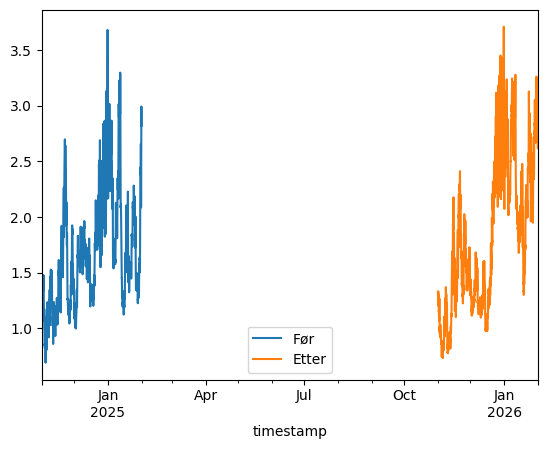

In [5]:
# Graf
before = df[df["norgespris"] == 0].groupby("timestamp")["value_kwh"].mean()
after = df[df["norgespris"] == 1].groupby("timestamp")["value_kwh"].mean()

import matplotlib.pyplot as plt

before.plot(label="Før")
after.plot(label="Etter")

plt.legend()
plt.show()

## Duplikater per id + timestamp

In [7]:
duplicates = df.duplicated(
    subset=["metering_point_anonymous", "timestamp"],
    keep=False
)

df[duplicates]

,metering_point_anonymous,timestamp,value_kwh,transformer_station,consumption_code,hour,weekday,month,is_weekend,is_holiday,day_night,norgespris


In [8]:
df.duplicated(
    subset=["metering_point_anonymous", "timestamp"]
).sum()

np.int64(0)

## Feature engineering

In [9]:
# hour, weekday, month
df["hour_check"] = df["timestamp"].dt.hour
df["weekday_check"] = df["timestamp"].dt.weekday
df["month_check"] = df["timestamp"].dt.month

df[
    (df["hour"] != df["hour_check"]) |
    (df["weekday"] != df["weekday_check"]) |
    (df["month"] != df["month_check"])
]

,metering_point_anonymous,timestamp,value_kwh,transformer_station,consumption_code,hour,weekday,month,is_weekend,is_holiday,day_night,norgespris,hour_check,weekday_check,month_check


In [10]:
# is_weekend
df["is_weekend_check"] = df["timestamp"].dt.weekday >= 5

df[df["is_weekend"] != df["is_weekend_check"]]

,metering_point_anonymous,timestamp,value_kwh,transformer_station,consumption_code,hour,weekday,month,is_weekend,is_holiday,day_night,norgespris,hour_check,weekday_check,month_check,is_weekend_check


In [11]:
# is_holiday
df[df["is_holiday"] == True]["timestamp"].dt.date.unique()

array([datetime.date(2024, 12, 31), datetime.date(2025, 12, 31),
       datetime.date(2024, 12, 24), datetime.date(2025, 12, 24)],
      dtype=object)

In [12]:
# day_night
df["day_night_check"] = df["timestamp"].dt.hour.apply(
    lambda x: "day" if 6 <= x < 22 else "night"
)

df[df["day_night"] != df["day_night_check"]]

,metering_point_anonymous,timestamp,value_kwh,transformer_station,consumption_code,hour,weekday,month,is_weekend,is_holiday,day_night,norgespris,hour_check,weekday_check,month_check,is_weekend_check,day_night_check


## Norgespris

In [13]:
# Sjekk perioder
df.groupby("norgespris")["timestamp"].agg(["min", "max"])

,min,max
norgespris,,
0,2024-11-01,2025-01-31 23:00:00
1,2025-11-01,2026-01-31 23:00:00


In [14]:
# Sjekke for null-verdier
df["norgespris"].value_counts(dropna=False)

norgespris
0    2918976
1    2918976
Name: count, dtype: int64

## Datakvalitets rapport

In [18]:
def data_quality_report(df):
    print("=== GENERELT ===")
    print("Antall rader:", len(df))
    print("Antall unike ID-er:", df["metering_point_anonymous"].nunique())
    
    print("\n=== MISSING VALUES ===")
    print(df.isna().sum())

    print("\n=== DUPLIKATER (ID + timestamp) ===")
    dup = df.duplicated(subset=["metering_point_anonymous", "timestamp"]).sum()
    print("Antall duplikater:", dup)

    print("\n=== FORBRUK ===")
    print("Negative verdier:", (df["value_kwh"] < 0).sum())
    print("Nullverdier:", (df["value_kwh"] == 0).sum())
    
    print("\nPercentiler:")
    print(df["value_kwh"].quantile([0.5, 0.9, 0.99, 0.999]))

    print("\n=== EKSTREME VERDIER (TOP 5) ===")
    print(df.nlargest(5, "value_kwh")[["metering_point_anonymous", "timestamp", "value_kwh"]])

    print("\n=== TIDSSERIE (PER ID) ===")
    df_sorted = df.sort_values(["metering_point_anonymous", "timestamp"])
    df_sorted["diff"] = df_sorted.groupby("metering_point_anonymous")["timestamp"].diff()
    
    wrong_diff = (df_sorted["diff"] != pd.Timedelta(hours=1)).sum()
    print("Avvik fra 1 time intervall:", wrong_diff)

    print("\n=== FEATURE ENGINEERING ===")
    errors = 0
    
    errors += (df["hour"] != df["timestamp"].dt.hour).sum()
    errors += (df["weekday"] != df["timestamp"].dt.weekday).sum()
    errors += (df["month"] != df["timestamp"].dt.month).sum()
    
    weekend_check = df["timestamp"].dt.weekday >= 5
    errors += (df["is_weekend"] != weekend_check).sum()

    print("Antall avvik i features:", errors)

    print("\n=== HOLIDAYS ===")
    holiday_dates = df[df["is_holiday"] == True]["timestamp"].dt.date.unique()
    print("Antall unike holiday-datoer:", len(holiday_dates))

    print("\n=== NORGESPRIS ===")
    print(df["norgespris"].value_counts(dropna=False))

    print("\nPerioder per norgespris:")
    print(df.groupby("norgespris")["timestamp"].agg(["min", "max"]))

    outside = df[~df["norgespris"].isin([0, 1])]
    print("\nObservasjoner utenfor perioder:", len(outside))

    print("\n=== SAMMENLIGNBARHET ===")
    print("Observasjoner per periode:")
    print(df["norgespris"].value_counts())

    print("\nUnike ID-er per periode:")
    print(df.groupby("norgespris")["metering_point_anonymous"].nunique())

    print("\nSnitt forbruk per periode:")
    print(df.groupby("norgespris")["value_kwh"].mean())

In [19]:
data_quality_report(df)

=== GENERELT ===
Antall rader: 5837952
Antall unike ID-er: 1322

=== MISSING VALUES ===
metering_point_anonymous    0
timestamp                   0
value_kwh                   0
transformer_station         0
consumption_code            0
hour                        0
weekday                     0
month                       0
is_weekend                  0
is_holiday                  0
day_night                   0
norgespris                  0
hour_check                  0
weekday_check               0
month_check                 0
is_weekend_check            0
day_night_check             0
dtype: int64

=== DUPLIKATER (ID + timestamp) ===
Antall duplikater: 0

=== FORBRUK ===
Negative verdier: 0
Nullverdier: 36269

Percentiler:
0.500     1.26
0.900     3.67
0.990     8.29
0.999    25.20
Name: value_kwh, dtype: float64

=== EKSTREME VERDIER (TOP 5) ===
                     metering_point_anonymous           timestamp  value_kwh
3993896  aea9acb1-ffee-4f37-bf7d-fce12308b142 2026-01-08 1